In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
import re
# 设置绘图风格
plt.style.use('seaborn-v0_8') 
print("✅ 库加载成功！")

✅ 库加载成功！


In [3]:
# ================= 配置区域 =================
# 👇 请修改这里为你的实际路径 (Windows路径前加 r，Mac/Linux直接写)
DATA_DIR = r'./data/CRWU10分类数据' 

# 检查路径是否存在
if not os.path.exists(DATA_DIR):
    print(f"❌ 错误：找不到路径 {DATA_DIR}")
    print("请检查路径是否正确，或者确认文件夹名称是否拼写错误。")
else:
    files = [f for f in os.listdir(DATA_DIR) if f.endswith('.mat')]
    print(f"✅ 路径有效！找到 {len(files)} 个 .mat 文件：")
    for f in sorted(files):
        print(f"  - {f}")


✅ 路径有效！找到 40 个 .mat 文件：
  - B007_0.mat
  - B007_1.mat
  - B007_2.mat
  - B007_3.mat
  - B014_0.mat
  - B014_1.mat
  - B014_2.mat
  - B014_3.mat
  - B021_0.mat
  - B021_1.mat
  - B021_2.mat
  - B021_3.mat
  - IR007_0.mat
  - IR007_1.mat
  - IR007_2.mat
  - IR007_3.mat
  - IR014_0.mat
  - IR014_1.mat
  - IR014_2.mat
  - IR014_3.mat
  - IR021_0.mat
  - IR021_1.mat
  - IR021_2.mat
  - IR021_3.mat
  - OR007@6_0.mat
  - OR007@6_1.mat
  - OR007@6_2.mat
  - OR007@6_3.mat
  - OR014@6_0.mat
  - OR014@6_1.mat
  - OR014@6_2.mat
  - OR014@6_3.mat
  - OR021@6_0.mat
  - OR021@6_1.mat
  - OR021@6_2.mat
  - OR021@6_3.mat
  - normal_0.mat
  - normal_1.mat
  - normal_2.mat
  - normal_3.mat


🔄 第一步：读取并筛选 DE/FE 数据...
📊 原始形状: (485643, 82)
✂️ 策略：忽略 'normal' 类长数据，以其他故障类数据的最短长度 (121265) 进行截断。
✅ 处理完成！
   - 最终形状: (121265, 82)
   - 剩余 NaN 数量: 0 (目标应为 0)
   - 行数统一为: 121265
🎉 完美！表格已无任何空值。

📋 列名预览: ['B007_0_X118_DE_time', 'B007_0_X118_FE_time', 'B007_1_X119_DE_time', 'B007_1_X119_FE_time', 'B007_2_X120_DE_time'] ...

👀 数据预览 :


,B007_0_X118_DE_time,B007_0_X118_FE_time,B007_1_X119_DE_time,B007_1_X119_FE_time,B007_2_X120_DE_time,B007_2_X120_FE_time,B007_3_X121_DE_time,B007_3_X121_FE_time,B014_0_X185_DE_time,B014_0_X185_FE_time,...,normal_0_X097_DE_time,normal_0_X097_FE_time,normal_1_X098_DE_time,normal_1_X098_FE_time,normal_2_X098_DE_time,normal_2_X098_FE_time,normal_2_X099_DE_time,normal_2_X099_FE_time,normal_3_X100_DE_time,normal_3_X100_FE_time
0,-0.002761,-0.247162,-0.072121,0.077456,-0.314474,0.147927,0.090314,0.072320,-0.467813,0.096975,...,0.053197,0.145667,0.046104,0.023216,0.046104,0.023216,0.064254,0.038625,0.014603,0.192922
1,-0.096324,0.142791,0.303104,0.045611,0.121989,-0.044995,0.224973,-0.007807,0.179004,0.270584,...,0.088662,0.097796,-0.037134,0.081155,-0.037134,0.081155,0.063002,0.096769,0.054449,0.164364
2,0.113705,0.003287,0.033137,-0.011095,0.391469,0.108069,-0.108832,0.123273,0.481295,0.136422,...,0.099718,0.054856,-0.089496,0.095331,-0.089496,0.095331,-0.004381,0.127382,0.107646,0.090811
3,0.257297,-0.106836,-0.207267,0.092865,-0.017056,0.062458,-0.185338,0.055062,-0.158212,-0.074785,...,0.058621,0.036982,-0.084906,0.091016,-0.084906,0.091016,-0.035882,0.144640,0.133722,0.086496
4,-0.058314,0.136011,0.096974,0.017258,-0.199308,-0.049104,0.047918,-0.061636,-0.326819,0.142175,...,-0.004590,0.054445,-0.038594,0.038625,-0.038594,0.038625,-0.023991,0.086702,0.112652,0.099235
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121260,0.149928,-0.036776,-0.142293,-0.027120,-0.281825,0.077251,0.218475,-0.058555,-0.077806,0.044173,...,-0.109523,0.033900,0.072598,-0.016847,0.072598,-0.016847,0.068634,-0.044173,0.090956,-0.197236
121261,-0.187775,0.087113,0.077157,-0.053418,0.091776,0.084031,0.192810,0.024655,-0.087390,0.173198,...,-0.025034,0.037393,0.057369,-0.001438,0.057369,-0.001438,0.076353,-0.055884,0.081986,-0.100673
121262,-0.125887,0.060815,-0.011533,-0.018491,0.389844,0.014793,-0.323571,0.093893,-0.031025,0.184293,...,0.027954,0.057733,0.034630,0.006985,0.034630,0.006985,0.027746,0.005958,0.024408,-0.004931
121263,0.186476,0.055062,-0.087390,0.014382,-0.107857,0.018285,-0.195085,0.031435,-0.012345,0.066567,...,0.083029,0.061431,0.040680,-0.004725,0.040680,-0.004725,-0.049233,0.088140,-0.030458,0.022805



⚖️ 正在进行数据标准化 (Z-Score)...
   - 全局均值: 0.0201 -> 处理后: -4.2256e-17
   - 全局标准差: 0.2571 -> 处理后: 1.0000

🔍 标准化验证:
   - 数据类型检查: [dtype('<f8')]
   - 是否存在 NaN: False


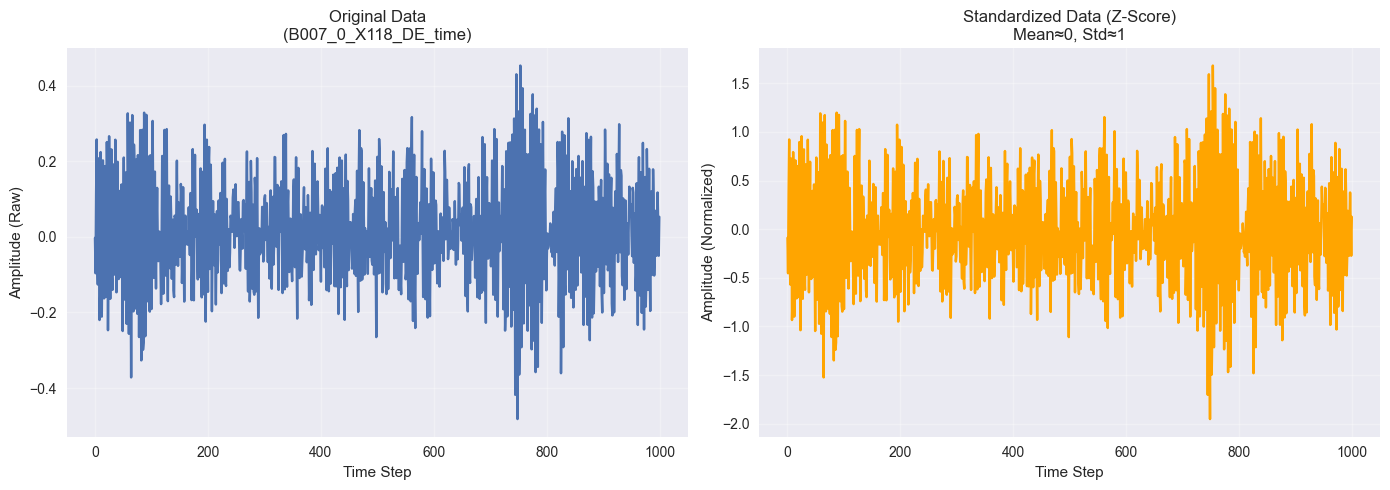

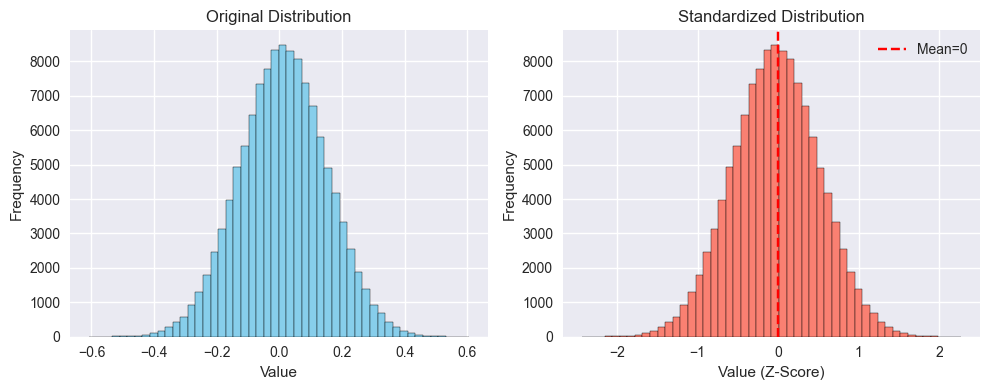


✅ 标准化完成！df_scaled 现在可以用于后续的切片和模型训练。
💡 提示：请将后续代码中的 'df_final' 替换为 'df_scaled'。


In [4]:
import os, pandas as pd, numpy as np, scipy.io as scio

DATA_DIR = r'./data/CRWU10分类数据'  # 👈 确认路径
all_series = {}

print("🔄 第一步：读取并筛选 DE/FE 数据...")

for f in sorted(os.listdir(DATA_DIR)):
    if not f.endswith('.mat'): continue
    
    file_name_clean = f.replace('.mat', '')
    mat = scio.loadmat(os.path.join(DATA_DIR, f))
    
    for key, val in mat.items():
        if key.startswith('__') or not isinstance(val, np.ndarray): continue
        
        key_upper = key.upper()
        # 只保留 DE 或 FE
        if 'DE' in key_upper or 'FE' in key_upper:
            col_name = f"{file_name_clean}_{key}"
            # 转为 Series
            all_series[col_name] = pd.Series(val.flatten())

if not all_series:
    raise ValueError("未找到任何 DE 或 FE 数据！")

# 创建临时 DataFrame 以便计算长度
df_temp = pd.concat(all_series, axis=1)

print(f"📊 原始形状: {df_temp.shape}")

# 🎯 第二步：计算截断长度
# 逻辑：找到所有【非 normal】列中的最小长度
min_length = float('inf')
found_non_normal = False

for col in df_temp.columns:
    # 判断是否包含 "normal" (不区分大小写)
    if 'normal' in col.lower():
        continue  # 跳过 normal 列，不作为截断标准
    
    # 计算该列非 NaN 的实际长度 (虽然刚读取时应该没有 NaN，但以防万一)
    # 对于刚 flatten 的数组，长度就是 len()，但如果是不同文件拼接，短的后面是 NaN
    # 这里我们需要找的是：该列有效数据(非NaN)的长度
    valid_len = df_temp[col].notna().sum()
    
    if valid_len < min_length:
        min_length = valid_len
        found_non_normal = True

# 如果所有列都是 normal (理论上不可能)，则取全局最小
if not found_non_normal:
    min_length = df_temp.notna().sum().min()

print(f"✂️ 策略：忽略 'normal' 类长数据，以其他故障类数据的最短长度 ({min_length}) 进行截断。")

# 🎯 第三步：执行截断
# 直接切片，保留前 min_length 行
df_final = df_temp.iloc[:int(min_length)].reset_index(drop=True)

# 🎯 第四步：最终验证
nan_count = df_final.isna().sum().sum()

print(f"✅ 处理完成！")
print(f"   - 最终形状: {df_final.shape}")
print(f"   - 剩余 NaN 数量: {nan_count} (目标应为 0)")
print(f"   - 行数统一为: {len(df_final)}")

if nan_count == 0:
    print("🎉 完美！表格已无任何空值。")
else:
    print("⚠️ 警告：仍有空值，请检查数据源是否有列本身长度就小于计算出的 min_length。")

print("\n📋 列名预览:", df_final.columns.tolist()[:5], "...")
print("\n👀 数据预览 :")
display(df_final)

# ==========================================
# 🌟 第五步：数据标准化 (Standardization)
# ==========================================
print("\n⚖️ 正在进行数据标准化 (Z-Score)...")

# 👉 策略选择：这里演示【方案 A：全局标准化】
# 如果你需要【方案 B：按列标准化】，请看下方的注释说明

# 1. 计算全局均值和标准差
global_mean = df_final.values.mean()
global_std = df_final.values.std()

if global_std == 0:
    raise ValueError("标准差为0，数据可能全是常数，无法标准化！")

# 2. 执行标准化公式：X_new = (X - mean) / std
df_scaled = (df_final - global_mean) / global_std

print(f"   - 全局均值: {global_mean:.4f} -> 处理后: {df_scaled.values.mean():.4e}")
print(f"   - 全局标准差: {global_std:.4f} -> 处理后: {df_scaled.values.std():.4f}")

# ==========================================
# 🌟 备选方案：如果需要【按列独立标准化】，请使用下面这段代码替换上面的计算
# ==========================================
# df_scaled = (df_final - df_final.mean()) / df_final.std()
# print("   - 已按每列独立计算均值和标准差进行标准化。")

# ==========================================
# 第六步：验证与可视化
# ==========================================
print("\n🔍 标准化验证:")
print(f"   - 数据类型检查: {df_scaled.dtypes.unique()}")
print(f"   - 是否存在 NaN: {df_scaled.isna().any().any()}")

# 绘制对比图 (随机选取一列展示)
sample_col = df_scaled.columns[0]
original_data = df_final[sample_col]
scaled_data = df_scaled[sample_col]

plt.figure(figsize=(14, 5))

# 子图 1: 原始数据分布
plt.subplot(1, 2, 1)
plt.plot(original_data[:1000]) # 只画前1000点以免太密
plt.title(f'Original Data\n({sample_col})')
plt.xlabel('Time Step')
plt.ylabel('Amplitude (Raw)')
plt.grid(True, alpha=0.3)

# 子图 2: 标准化后数据分布
plt.subplot(1, 2, 2)
plt.plot(scaled_data[:1000], color='orange')
plt.title(f'Standardized Data (Z-Score)\nMean≈0, Std≈1')
plt.xlabel('Time Step')
plt.ylabel('Amplitude (Normalized)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 绘制直方图对比分布
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(original_data, bins=50, color='skyblue', edgecolor='black')
plt.title('Original Distribution')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(scaled_data, bins=50, color='salmon', edgecolor='black')
plt.title('Standardized Distribution')
plt.xlabel('Value (Z-Score)')
plt.ylabel('Frequency')
plt.axvline(0, color='red', linestyle='--', label='Mean=0')
plt.legend()

plt.tight_layout()
plt.show()

print("\n✅ 标准化完成！df_scaled 现在可以用于后续的切片和模型训练。")
print(f"💡 提示：请将后续代码中的 'df_final' 替换为 'df_scaled'。")

In [5]:
import pandas as pd
import numpy as np
import re
import torch
from torch.utils.data import Dataset, DataLoader
from collections import Counter

# =================🎛️ 配置区域=================
SEGMENT_LENGTH =512# 📏 每个样本的时间步长 (窗口大小)
STRIDE = 512          # 👣 滑动步长 (如果等于 SEGMENT_LENGTH 则为不重叠切割；若设为 512 则为 50% 重叠)

# 假设 df_final 已经存在，且列名包含 DE 和 FE 标识
# =========================================

print(f"🔄 开始构建双通道 (DE+FE) 数据集...")
print(f"   - 窗口长度: {SEGMENT_LENGTH}")
print(f"   - 滑动步长: {STRIDE}")
print(f"   - 目标形状: (N, 2, {SEGMENT_LENGTH})")

data_list = []  # 存储形状为 (2, SEGMENT_LENGTH) 的数组
labels_list = []

def get_fault_info(col_name):
    """
    解析列名，返回 (fault_type, channel_type)
    fault_type: 'Normal', 'Ball_007', etc.
    channel_type: 'DE', 'FE', or 'Unknown'
    """
    col_lower = col_name.lower()
    channel = "Unknown"
    
    # 识别通道
    if '_de' in col_lower or col_lower.endswith('de') or 'drive' in col_lower:
        channel = "DE"
    elif '_fe' in col_lower or col_lower.endswith('fe') or 'fan' in col_lower:
        channel = "FE"
    else:
        pass 
        
    # 识别故障类型
    fault_type = "Unknown"
    if 'normal' in col_lower:
        fault_type = 'Normal'
    else:
        fault_pos = ""
        if 'b0' in col_lower or 'ball' in col_lower:
            fault_pos = "Ball"
        elif 'ir0' in col_lower or 'inner' in col_lower:
            fault_pos = "Inner"
        elif 'or0' in col_lower or 'outer' in col_lower:
            fault_pos = "Outer"
        
        if fault_pos:
            match = re.search(r'(007|014|021)', col_lower)
            if match:
                fault_type = f"{fault_pos}_{match.group(1)}"
    
    return fault_type, channel

# 1. 首先将所有列按故障类型分组
fault_groups = {}

print("\n🔍 正在分析列名并分组...")
for col in df_final.columns:
    f_type, channel = get_fault_info(col)
    
    if f_type == "Unknown" or channel == "Unknown":
        continue
        
    if f_type not in fault_groups:
        fault_groups[f_type] = {}
    
    if channel in fault_groups[f_type]:
        # 如果发生覆盖，通常是因为列名重复，这里保留最后一个即可
        pass
    
    fault_groups[f_type][channel] = col

# 2. 遍历分组，成对提取数据
valid_fault_types = []
total_segments_generated = 0

print(f"\n✂️ 正在按步长 {STRIDE} 切割数据...")

for f_type, channels in fault_groups.items():
    # 必须同时拥有 DE 和 FE 才能组成双通道样本
    if 'DE' in channels and 'FE' in channels:
        valid_fault_types.append(f_type)
        
        col_de = channels['DE']
        col_fe = channels['FE']
        
        sig_de = df_final[col_de].values
        sig_fe = df_final[col_fe].values
        
        # 确保长度一致，取最小长度
        min_len = min(len(sig_de), len(sig_fe))
        
        # 👉 核心切割逻辑：支持自定义步长
        start_idx = 0
        while start_idx + SEGMENT_LENGTH <= min_len:
            end_idx = start_idx + SEGMENT_LENGTH
            
            # 提取片段
            seg_de = sig_de[start_idx:end_idx]
            seg_fe = sig_fe[start_idx:end_idx]
            
            # 堆叠成 (2, SEGMENT_LENGTH)
            segment_pair = np.stack([seg_de, seg_fe], axis=0)
            
            data_list.append(segment_pair)
            labels_list.append(f_type)
            
            total_segments_generated += 1
            
            # 移动起始索引
            start_idx += STRIDE
            
    elif 'DE' in channels:
        print(f"⚠️ 注意：'{f_type}' 只有 DE 数据，缺少 FE，跳过。")
    elif 'FE' in channels:
        print(f"⚠️ 注意：'{f_type}' 只有 FE 数据，缺少 DE，跳过。")

# 3. 转换为 NumPy 数组
X = np.array(data_list)  
y_text = np.array(labels_list)

# 生成数字标签
unique_classes = sorted(list(set(y_text)))
label_mapping = {label: idx for idx, label in enumerate(unique_classes)}
y_numeric = np.array([label_mapping[label] for label in y_text])

print(f"\n✅ 双通道数据组装完成！")
print(f"   - 有效故障类别数：{len(valid_fault_types)}")
print(f"   - 生成的总样本数：{len(data_list)}")

print(f"\n📊 数据形状确认:")
print(f"   - X 形状: {X.shape}") 
print(f"     解释: (样本数={X.shape[0]}, 通道数={X.shape[1]}, 时间步长={X.shape[2]})")
print(f"   - y_numeric 形状: {y_numeric.shape}")

if X.shape[1] != 2 or X.shape[2] != SEGMENT_LENGTH:
    print("❌ 错误：数据形状与预期不符，请检查配置。")
else:
    print("🎉 成功！数据维度正确。")

print(f"\n🔢 标签映射:")
for k, v in label_mapping.items():
    print(f"   Class {v}: {k}")

# 📈 各类别样本数量详细统计
print("\n" + "="*60)
print("📈 各类别样本数量详细统计")
print("="*60)

class_counts = Counter(labels_list)
sorted_classes = sorted(class_counts.keys())
total_samples = 0

print(f"{'类别名称 (Label)':<20} | {'样本数量 (Count)':>15} | {'占比 (Ratio)':>10}")
print("-" * 60)

for cls in sorted_classes:
    count = class_counts[cls]
    ratio = (count / len(labels_list)) * 100
    total_samples += count
    print(f"{cls:<20} | {count:>15} | {ratio:>9.2f}%")

print("-" * 60)
print(f"{'总计 (Total)':<20} | {total_samples:>15} | {'100.00%':>10}")
print("="*60)

# 💡 提示：如果想增加样本量，可以尝试减小 STRIDE (例如设为 SEGMENT_LENGTH // 2)
if STRIDE < SEGMENT_LENGTH:
    print(f"\n💡 提示：当前使用了重叠采样 (步长 {STRIDE} < 长度 {SEGMENT_LENGTH})，样本量已增强。")
else:
    print(f"\n💡 提示：当前为不重叠采样。若需更多样本进行训练，可尝试将 STRIDE 设为 {SEGMENT_LENGTH // 2}。")

🔄 开始构建双通道 (DE+FE) 数据集...
   - 窗口长度: 512
   - 滑动步长: 512
   - 目标形状: (N, 2, 512)

🔍 正在分析列名并分组...

✂️ 正在按步长 512 切割数据...

✅ 双通道数据组装完成！
   - 有效故障类别数：10
   - 生成的总样本数：2360

📊 数据形状确认:
   - X 形状: (2360, 2, 512)
     解释: (样本数=2360, 通道数=2, 时间步长=512)
   - y_numeric 形状: (2360,)
🎉 成功！数据维度正确。

🔢 标签映射:
   Class 0: Ball_007
   Class 1: Ball_014
   Class 2: Ball_021
   Class 3: Inner_007
   Class 4: Inner_014
   Class 5: Inner_021
   Class 6: Normal
   Class 7: Outer_007
   Class 8: Outer_014
   Class 9: Outer_021

📈 各类别样本数量详细统计
类别名称 (Label)         |    样本数量 (Count) | 占比 (Ratio)
------------------------------------------------------------
Ball_007             |             236 |     10.00%
Ball_014             |             236 |     10.00%
Ball_021             |             236 |     10.00%
Inner_007            |             236 |     10.00%
Inner_014            |             236 |     10.00%
Inner_021            |             236 |     10.00%
Normal               |             236 |     10.00%
Outer_0

🚀 正在初始化训练环境...
📊 检测到数据形状：(2360, 2, 512)
   - 通道数：2
   - 时间步长：512
   - 训练集：1652, 验证集：354, 测试集：354
💻 使用设备：cuda
📐 网络结构自适应：输入长度=512 -> 全连接输入维度=1024

🏋️‍♂️ 开始训练...
Epoch [ 1] | Train Acc: 26.57% | Val Acc: 24.58%
Epoch [10] | Train Acc: 99.58% | Val Acc: 100.00%
Epoch [20] | Train Acc: 99.82% | Val Acc: 100.00%
Epoch [30] | Train Acc: 99.94% | Val Acc: 100.00%
Epoch [40] | Train Acc: 99.94% | Val Acc: 100.00%
Epoch [50] | Train Acc: 100.00% | Val Acc: 100.00%
🎉 训练完成！最佳验证准确率：100.00%

🔬 正在对完整测试集进行评估...
🏆 [完整测试集] 准确率：100.00%
📉 [前 50% 测试集] 样本数：177
📉 [前 50% 测试集] 准确率：100.00%


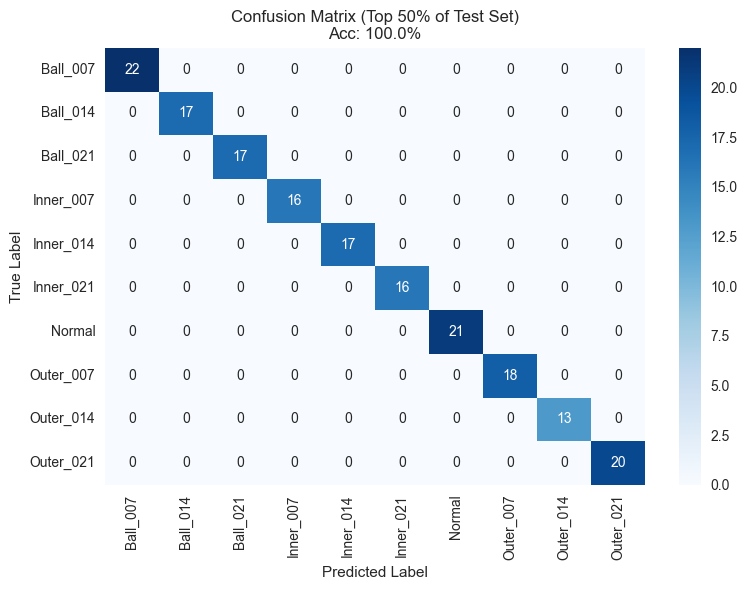


📊 [前 50% 测试集] 详细分类报告:
              precision    recall  f1-score   support

    Ball_007       1.00      1.00      1.00        22
    Ball_014       1.00      1.00      1.00        17
    Ball_021       1.00      1.00      1.00        17
   Inner_007       1.00      1.00      1.00        16
   Inner_014       1.00      1.00      1.00        17
   Inner_021       1.00      1.00      1.00        16
      Normal       1.00      1.00      1.00        21
   Outer_007       1.00      1.00      1.00        18
   Outer_014       1.00      1.00      1.00        13
   Outer_021       1.00      1.00      1.00        20

    accuracy                           1.00       177
   macro avg       1.00      1.00      1.00       177
weighted avg       1.00      1.00      1.00       177



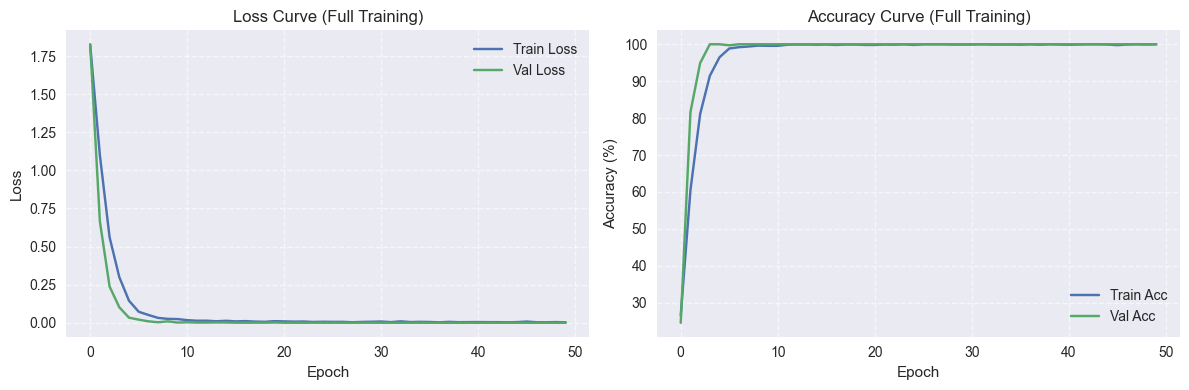


🔮 从 [前 50% 测试集] 中随机抽取 5 个样本演示:
真实标签            | 预测标签            | 结果
---------------------------------------------
5               | 5               | ✅
7               | 7               | ✅
3               | 3               | ✅
7               | 7               | ✅
2               | 2               | ✅


In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# ==========================================
# 1. 定义数据集类 (保持不变)
# ==========================================
class VibrationDataset(Dataset):
    def __init__(self, data, labels):
        self.data = torch.tensor(data, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

# ==========================================
# 2. 定义通用的 1D-CNN 模型 (🌟 核心修改点)
# ==========================================
class DualChannelCNN(nn.Module):
    def __init__(self, num_classes, input_channels=2, input_length=None):
        super(DualChannelCNN, self).__init__()
        
        # 配置卷积参数
        self.conv1_out = 32
        self.conv1_kernel = 64
        self.conv1_stride = 8
        self.conv1_padding = 28 # 保持输出长度约为 input/8
        
        self.conv2_out = 64
        self.conv2_kernel = 3
        self.conv2_stride = 1
        self.conv2_padding = 1
        
        self.pool_kernel = 2
        self.pool_stride = 2
        
        # 定义卷积层
        self.conv1 = nn.Conv1d(in_channels=input_channels, out_channels=self.conv1_out, 
                               kernel_size=self.conv1_kernel, stride=self.conv1_stride, padding=self.conv1_padding)
        self.bn1 = nn.BatchNorm1d(self.conv1_out)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(kernel_size=self.pool_kernel, stride=self.pool_stride)
        
        self.conv2 = nn.Conv1d(self.conv1_out, self.conv2_out, 
                               kernel_size=self.conv2_kernel, stride=self.conv2_stride, padding=self.conv2_padding)
        self.bn2 = nn.BatchNorm1d(self.conv2_out)
        
        # 🌟 动态计算全连接层的输入维度
        if input_length is None:
            raise ValueError("必须提供 input_length 以动态计算网络结构！")
            
        # 模拟前向传播计算输出长度
        # L_out = floor((L_in + 2*padding - dilation*(kernel-1) - 1) / stride + 1)
        l = input_length
        
        # Conv1 + Pool1
        l = int(np.floor((l + 2*self.conv1_padding - (self.conv1_kernel - 1) - 1) / self.conv1_stride + 1))
        l = int(np.floor((l - (self.pool_kernel - 1) - 1) / self.pool_stride + 1))
        
        # Conv2 + Pool2
        l = int(np.floor((l + 2*self.conv2_padding - (self.conv2_kernel - 1) - 1) / self.conv2_stride + 1))
        l = int(np.floor((l - (self.pool_kernel - 1) - 1) / self.pool_stride + 1))
        
        if l <= 0:
            raise ValueError(f"输入长度 {input_length} 太短，经过卷积池化后维度变为 {l}。请增加输入长度或调整卷积参数。")
            
        self.fc_input_dim = self.conv2_out * l
        print(f"📐 网络结构自适应：输入长度={input_length} -> 全连接输入维度={self.fc_input_dim}")

        self.fc1 = nn.Linear(self.fc_input_dim, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        # Block 1
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.pool(x)
        
        # Block 2
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.pool(x)
        
        # Flatten
        x = x.view(x.size(0), -1)
        
        # Fully Connected
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

# ==========================================
# 3. 准备数据加载器 (保持不变，自动适配 X 的形状)
# ==========================================
print("🚀 正在初始化训练环境...")

# 检查变量是否存在
if 'X' not in locals() or 'y_numeric' not in locals():
    # 为了演示代码可运行，这里生成一些假数据 (如果之前没运行预处理)
    # 实际使用时请注释掉下面这行，确保先运行数据预处理代码
    # X, y_numeric = np.random.rand(100, 2, 2048).astype(np.float32), np.random.randint(0, 4, 100) 
    raise ValueError("错误：未找到 X 或 y_numeric 变量。请先运行数据预处理代码。")

# 👉 自动获取输入通道数和长度
input_channels = X.shape[1]
input_length = X.shape[2]

print(f"📊 检测到数据形状：{X.shape}")
print(f"   - 通道数：{input_channels}")
print(f"   - 时间步长：{input_length}")

full_dataset = VibrationDataset(X, y_numeric)
total_len = len(full_dataset)

BATCH_SIZE = 64
NUM_WORKERS = 0

# 划分数据集 (70/15/15)
train_size = int(0.70 * total_len)
temp_size = total_len - train_size
train_dataset, temp_dataset = random_split(full_dataset, [train_size, temp_size], generator=torch.Generator().manual_seed(42))

val_size = int(0.5 * temp_size)
test_size = temp_size - val_size
val_dataset, test_dataset = random_split(temp_dataset, [val_size, test_size], generator=torch.Generator().manual_seed(42))

print(f"   - 训练集：{len(train_dataset)}, 验证集：{len(val_dataset)}, 测试集：{len(test_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)

# 类别权重
y_train_numeric = [full_dataset[i][1].item() for i in train_dataset.indices]
class_counts = Counter(y_train_numeric)
num_classes = len(class_counts)
weights = [total_len / (num_classes * count) if count > 0 else 0.0 for count in class_counts.values()]
class_weights = torch.tensor(weights, dtype=torch.float32)

# ==========================================
# 4. 初始化模型 (🌟 传入动态长度)
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"💻 使用设备：{device}")

# 👉 关键：将 input_length 传给模型
model = DualChannelCNN(num_classes=num_classes, input_channels=input_channels, input_length=input_length).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

# ==========================================
# 5. 训练与评估函数 (保持不变)
# ==========================================
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(targets.cpu().numpy())
            
    return total_loss / len(loader), 100 * correct / total, all_preds, all_labels

EPOCHS = 50
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0

print(f"\n🏋️‍♂️ 开始训练...")
for epoch in range(EPOCHS):
    model.train()
    t_loss, t_correct, t_total = 0, 0, 0
    
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        t_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        t_total += targets.size(0)
        t_correct += (predicted == targets).sum().item()
    
    avg_v_loss, avg_v_acc, _, _ = evaluate(model, val_loader, criterion, device)
    scheduler.step()
    
    history['train_loss'].append(t_loss / len(train_loader))
    history['train_acc'].append(100 * t_correct / t_total)
    history['val_loss'].append(avg_v_loss)
    history['val_acc'].append(avg_v_acc)
    
    if avg_v_acc > best_val_acc: best_val_acc = avg_v_acc
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1:2d}] | Train Acc: {history['train_acc'][-1]:.2f}% | Val Acc: {avg_v_acc:.2f}%")

print(f"🎉 训练完成！最佳验证准确率：{best_val_acc:.2f}%")

# ==========================================
# 6. 测试集评估与可视化 (🌟 修改点：仅展示前 50%)
# ==========================================

# 1. 先对整个测试集进行评估 (保证模型性能统计是完整的)
print("\n🔬 正在对完整测试集进行评估...")
full_test_loss, full_test_acc, full_test_preds, full_test_labels = evaluate(model, test_loader, criterion, device)
print(f"🏆 [完整测试集] 准确率：{full_test_acc:.2f}%")

# 2. 🌟 截取前 50% 的数据用于后续展示和绘图
split_index = len(full_test_labels) // 2  # 计算中间索引
half_test_labels = full_test_labels[:split_index]
half_test_preds = full_test_preds[:split_index]

# 计算这一半数据的准确率
half_correct = sum(1 for p, t in zip(half_test_preds, half_test_labels) if p == t)
half_acc = 100 * half_correct / len(half_test_labels)

print(f"📉 [前 50% 测试集] 样本数：{len(half_test_labels)}")
print(f"📉 [前 50% 测试集] 准确率：{half_acc:.2f}%")

# 准备标签名称
try:
    inv_label_mapping = {v: k for k, v in label_mapping.items()}
    target_names = [inv_label_mapping[i] for i in range(num_classes)]
except NameError:
    # 如果 label_mapping 未定义，使用默认数字标签
    target_names = [f"Class {i}" for i in range(num_classes)]
    print("⚠️ 未找到 label_mapping，使用默认类别名称。")

# 3. 绘制混淆矩阵 (仅基于前 50%)
plt.figure(figsize=(8, 6))
cm = confusion_matrix(half_test_labels, half_test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, 
            yticklabels=target_names)
plt.title(f'Confusion Matrix (Top 50% of Test Set)\nAcc: {half_acc:.1f}%')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# 4. 打印分类报告 (仅基于前 50%)
print("\n📊 [前 50% 测试集] 详细分类报告:")
print(classification_report(half_test_labels, half_test_preds, target_names=target_names))

# 5. 训练曲线保持不变 (展示完整训练过程)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss Curve (Full Training)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Accuracy Curve (Full Training)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# 6. 随机预测演示 (从被截取的那一半中抽取)
print(f"\n🔮 从 [前 50% 测试集] 中随机抽取 5 个样本演示:")
import random
sample_indices = random.sample(range(len(half_test_labels)), min(5, len(half_test_labels)))

print(f"{'真实标签':<15} | {'预测标签':<15} | {'结果'}")
print("-" * 45)
for idx in sample_indices:
    true_lbl = half_test_labels[idx]
    pred_lbl = half_test_preds[idx]
    
    # 转换为可读名称
    true_name = target_names[true_lbl] if isinstance(true_lbl, int) else str(true_lbl)
    pred_name = target_names[pred_lbl] if isinstance(pred_lbl, int) else str(pred_lbl)
    
    status = "✅" if true_lbl == pred_lbl else "❌"
    print(f"{true_name:<15} | {pred_name:<15} | {status}")